# Process List of NaI Calibration Data Files

This notebook develops and tests a function to process a list of HDF5 files that contains NaI data taken underground in Kamioka.

File comes in a few categories:
1. configuration (top, bottom, east, west, north, south, int)
2. runtype (background or calibration)

Therefore, **the top level is a string that describes the run type and configuration**. 

It will be named as **RunConfiguration-RunType**.
- Run configuration is either of the following
    - top, bottom, east, west, north, south, int
- Run type is one of the following
    - bkg, cal_source_name_-A (e.g. cal_cs_137)

Under each run type and configuration, each file corresponding to each hour will be indexed by the file number.

In [1]:
import pyradet.h5util.h5reader as h5reader
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import re
import glob

In [2]:
timestamp_kamioka = 1742871600
# timestamp of 12pm, 2025-03-25

## Function to Manipulate Text Files

Use regular expression to inspect the file name.

In [3]:
def extract_run_number(filename: str) -> int:
    """
    Given the filename, return the run number.
    This run number will be used as file index.
    """
    match = re.search(r"Run(\d+)", filename)
    if match:
        return int(match.group(1))
    else:
        return -1
        #raise ValueError("Run number not found in filename.")

def parse_filename(filename: str):
    """
    Given NaI background/calibration files in hdf5 format, named according to the following convention:
        NaI_Background/Calibration_Direction(_SourceAA)_RunXXX_YYYYMMDD_HHMMSS.hdf5
    where SourceAA is true only for the case of calibration
    This function returns the key to be associated with this file
    """

    # Match background: NaI_Background_<position>_...
    bg_pattern = r"NaI_Background_(top|bottom|east|west|south|north|int)_"
    bg_match = re.search(bg_pattern, filename, re.IGNORECASE)
    
    if bg_match:
        run_number = extract_run_number(filename)
        position = bg_match.group(1).lower()
        return f"{position}-bkg", run_number

    # Match calibration: NaI_Calibration_<position>_<isotope><mass>_...
    cal_pattern = r"NaI_Calibration_(top|bottom|east|west|south|north|int)_([A-Za-z]{1,2}\d{2,3})_"
    cal_match = re.search(cal_pattern, filename, re.IGNORECASE)
    if cal_match:
        position = cal_match.group(1).lower()
        source = cal_match.group(2)
        return f"{position}-cal-{source}", 0

    # If neither matched
    raise ValueError(f"Filename does not match expected pattern: {filename}")

def find_file_by_run_id(run_id, position, directory="."):
    # Capitalize the first character of the position
    position = position.capitalize()

    # Define the glob pattern using the capitalized position and run ID
    pattern = f"{directory}/NaI_*_{position}*Run{run_id}_*.hdf5"
    
    # Find matching files
    matches = glob.glob(pattern)
    
    # Return the matches (or the first match if you expect only one)
    return matches  # or return matches[0] if you expect exactly one file

from collections import defaultdict

def generate_file_dict( filelist ):
    """
        Returns a dictionary where key is description of filetype and value is a list of files belonging to the same type/configuration
    """
    ret = defaultdict(list)
    for file in filelist:
        config, runID = parse_filename( file )
        ret[config].append( file )
    return ret

## Given a text file, generate a list of files to be processed

In [4]:
def read_file_list(filename):
    """
    Reads a text file and returns a list of lines (file paths).
    Strips newlines and skips empty lines.
    """
    try:
        with open(filename, 'r') as file:
            file_list = [line.strip() for line in file if line.strip()]
        return file_list
    except FileNotFoundError:
        print(f"Error: The file '{filename}' was not found.")
        return []
        
listdir = './'
tmp = 'list_calibration.txt'

datafiles = read_file_list( listdir + tmp )
keys = [ parse_filename(i)[0] for i in datafiles ]
file_dict = generate_file_dict( datafiles )

#print( datafiles )
#print( keys )

# print only up to two files
for i,j in file_dict.items():
    print( i )
    print( file_dict[i][:2])

east-cal-Ba133
['NaI_Calibration_East_Ba133_HV800_20250404_120752.hdf5']
east-cal-Co57
['NaI_Calibration_East_Co57_HV800_20250404_102217.hdf5']
east-cal-Co60
['NaI_Calibration_East_Co60_HV800_20250404_113839.hdf5']
east-cal-Cs137
['NaI_Calibration_East_Cs137_HV800_20250404_115422.hdf5']
east-cal-Na22
['NaI_Calibration_East_Na22_HV800_20250404_112645.hdf5']
north-cal-Ba133
['NaI_Calibration_North_Ba133_HV800_20250404_140722.hdf5']
north-cal-Co57
['NaI_Calibration_North_Co57_HV800_20250404_123411.hdf5']
north-cal-Co60
['NaI_Calibration_North_Co60_HV800_20250404_134219.hdf5']
north-cal-Cs137
['NaI_Calibration_North_Cs137_HV800_20250404_135511.hdf5']
north-cal-Na22
['NaI_Calibration_North_Na22_HV800_20250404_142051.hdf5']
south-cal-Ba133
['NaI_Calibration_South_Ba133_HV800_20250402_120139.hdf5']
south-cal-Co57
['NaI_Calibration_South_Co57_HV800_20250402_103230.hdf5']
south-cal-Co60
['NaI_Calibration_South_Co60_HV800_20250402_114307.hdf5']
south-cal-Cs137
['NaI_Calibration_South_Cs137_HV800

---

## Functions to Process Waveform

In [5]:
def GetBaseline( array, pre_trig_window, n = 10 ):
    '''
    Returns the mean and standard deviation of the pre-trigger baseline
    '''
    avg = np.average( array[:pre_trig_window-n] )
    dev = np.std( array[:pre_trig_window-n] )
    return avg, dev
    
def GetPulseBegin( array, pre_trig_window, nSigma ):
    '''
    Returns the beginning of the pulse, aligned by the first deviation from baseline by N sigmas
    np.where() method returns a tuple with the first element being an array of indices that satisties the condition
    '''
    mean, dev = GetBaseline( array, pre_trig_window)
    arr_len = len(array[:pre_trig_window])
    return np.where( np.abs(array[:pre_trig_window]-mean*np.ones(arr_len) ) < nSigma * dev)[0][-1]

def GetPulseHeightEnergy( array, pre_trig_window, integration_window ):
    
    mean, dev = GetBaseline( array, pre_trig_window )
    
    array =  mean * np.ones( len(array) ) - array
        # get array to be positive polarity
    
    begin = GetPulseBegin( array, pre_trig_window, 1 )
    
    tmp = array[ begin - 4 : begin + integration_window ]

    return np.max(tmp), np.trapezoid(tmp) * 0.004    

---

## Master Function to Process Entire File

The output of this function is an **event matrix** containing reduced quantities of interest for analysis.

In [6]:
def ProcessFile( filenames ):
    """
    Processes specified file and return a matrix corresponding to the reduced quantities of events in the file
    """
    if isinstance(filenames, str):
        filenames = [filenames]
    
    channel = 0
    pre_trig_subtract = 10
    
    event_stat = []
        # result will be array of python tuples
    
    for filename in filenames:
        print( filename )

        run_number = extract_run_number( filename )
    
        reader = h5reader.DataReader( filename )
        reader.Open()

        adc_attr = reader.GetADCAttributes()
    
        pre_trigger_window = adc_attr['nb_pre_trigger_sample']
        threshold = adc_attr['channel_threshold']

        counter = 0

        for event_data, event_attr in reader.GetEventIterator():
    
            print( "- processing event {}".format(event_attr["index"]), end='\r' )

            array = event_data[channel]

            mean, dev = GetBaseline( array, pre_trigger_window )

            tmp4 = np.max( array )
                # maximum ADC count in the entire waveform
            tmp5 = np.min( array )
                # minimum ADC count in the entire waveform

            tmp6 = len( array[ array > (tmp4+tmp5)/2 ] ) / len(array)
                # fraction of waveform above the middle of the range
    
            # Now perform baseline subtraction and get energy information
            #        
            array_rev =  mean * np.ones( len(array) ) - array
                # use the entire array to calculate mean and fluctuation
    
            begin = GetPulseBegin( array_rev, pre_trigger_window, 1 )
    
            tmp = array_rev[ begin - 4 : begin + 500 ]
            energy1 = np.trapezoid(tmp) * 0.004
            height1 = np.max(tmp)
    
            tmp2 = array_rev[ begin + 500 : ]
            energy2 = np.trapezoid(tmp2) * 0.004
            height2 = np.max(tmp2)

            event_stat.append( [run_number,counter,mean,dev,tmp4,tmp5,tmp6,height1,energy1,height2,energy2,event_attr['timestamp']] )

            counter += 1
        
        reader.Close()
    
    print('')

    return np.array(event_stat)


def calculate_run_time( filenames ):
    """
    Calculates the runtime by subtracting the begin time from end time in Linux timestamp.
    """
    if isinstance(filenames, str):
        filenames = [filenames]

    output = []

    for f in filenames:
        reader = h5reader.DataReader( f )
        reader.Open()
        output.append( reader.GetAttributes()['timestamp_end'] - reader.GetAttributes()['timestamp'] )
        reader.Close()

    return output

--- 

# Energy Spectra

For each key (run type), process list of data files and generate an event matrix for all the runs.

In [8]:
filedir = 'data/20250325_NaI_Kamioka/'

event_dictionary = {}
runtime_dictionary = {}

load = True

if load:
    event_dictionary = np.load( 'data/20250325_NaI_Kamioka/calibration.npz' )
else:
    for i,j in file_dict.items():
    
        tmp_list = [ filedir + k for k in j ]
        runtime_dictionary[i] = np.sum( calculate_run_time(tmp_list) )
    
        event_matrix = ProcessFile( tmp_list )
        event_dictionary[i] = event_matrix

    np.savez('data/20250325_NaI_Kamioka/calibration.npz', **event_dictionary)

---

Make a preliminary plot of energy spectra

In [9]:
std_threshold = 5
max_limit = 4035
frac_above_middle = 0.9

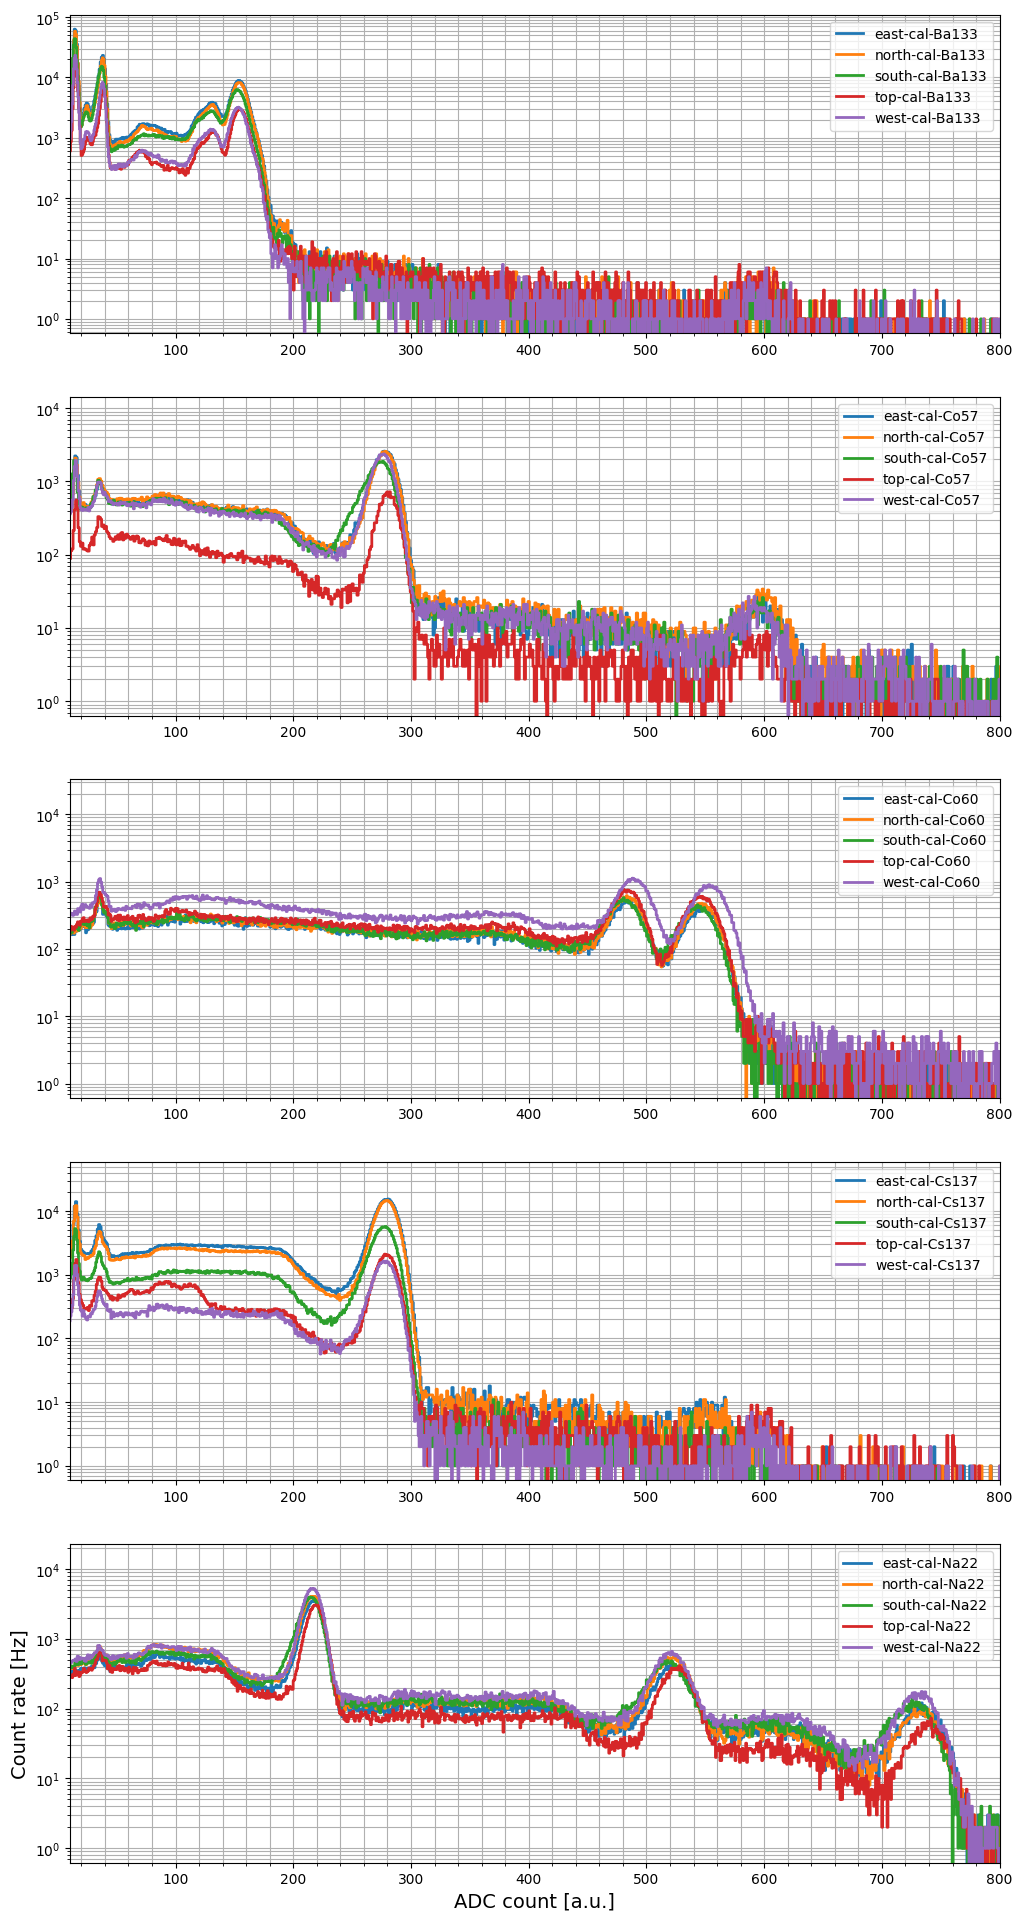

In [20]:
fig, ax = plt.subplots( 5, 1, figsize=(12,24) )

index = 0

for key, event_matrix in event_dictionary.items():

    #counts1, bin_edges = np.histogram( event_matrix[:,8], bins=1000 );
    #plt.step(bin_edges[:-1], counts1, where='mid', linewidth=2)

    #if 'east' in key:
    if True:

        cuts = (event_matrix[:,4] < max_limit) & (event_matrix[:,6] > frac_above_middle) & (event_matrix[:,3] < std_threshold) 
        counts2, bin_edges = np.histogram( event_matrix[cuts][:,8], bins=2000 );
        
        ax[index%5].step(bin_edges[:-1], counts2, where='mid', linewidth=2, label=key )

        ax[index%5].set_yscale('log')
        ax[index%5].set_xlim([10,800])

        ax[index%5].minorticks_on()
        ax[index%5].grid( which='both')

        ax[index%5].legend()

        index += 1

plt.xlabel('ADC count [a.u.]', fontsize=14)
plt.ylabel('Count rate [Hz]', fontsize=14)
plt.show()

---

## Baseline Stability

In this section, we will make scatter plots (2D histogram) of mean and standard deviation of baseline over time

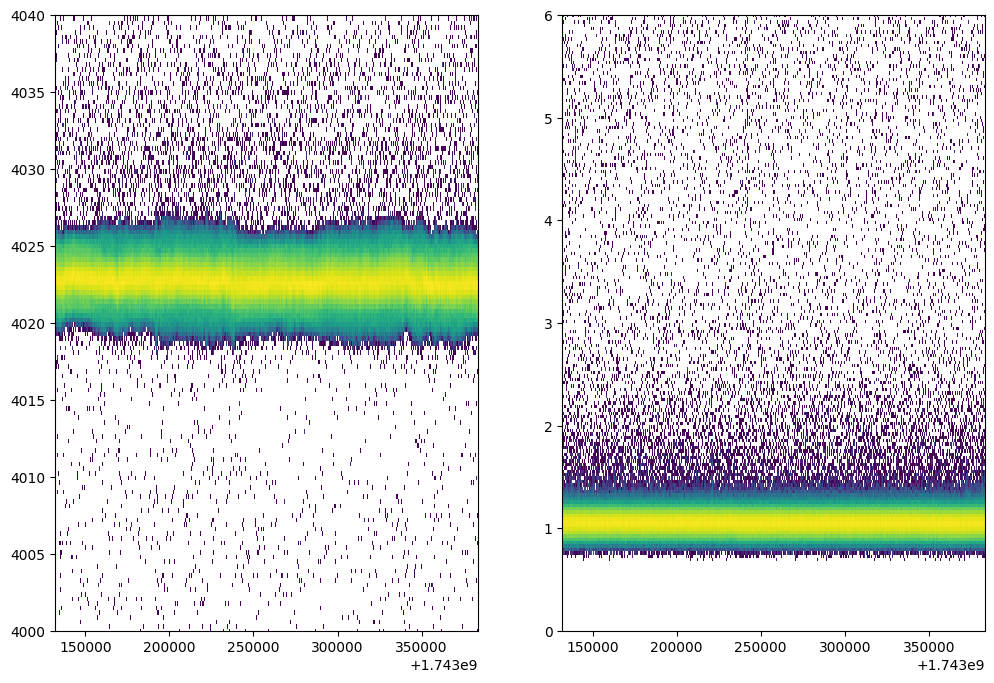

In [33]:
fig, ax = plt.subplots( 1, 2, figsize=(12,8) )

for key, event_matrix in event_dictionary.items():

    ax[0].hist2d( event_matrix[:,11], event_matrix[:,2], bins=(500,500), norm=matplotlib.colors.LogNorm())
    ax[1].hist2d( event_matrix[:,11], event_matrix[:,3], bins=(500,2000), norm=matplotlib.colors.LogNorm())

ax[0].set_ylim([4000,4040])
ax[1].set_ylim([0,6])
plt.show()

## Distribution of Noise Over Time

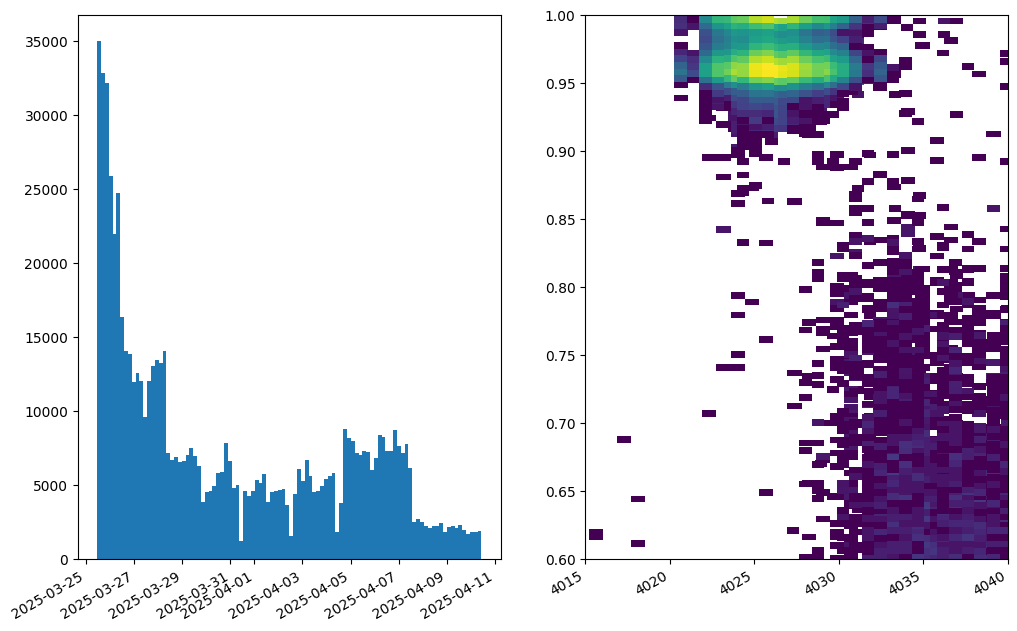

In [65]:
import datetime
import matplotlib.dates as mdates

fig, ax = plt.subplots( 1, 2, figsize=(12,8) )

noise_ts = []

for key, event_matrix in event_dictionary.items():

    mask = event_matrix[:,4] > 4028
    dates = [datetime.datetime.fromtimestamp(ts) for ts in event_matrix[mask][:,11] ]
    noise_ts.extend( dates )

    ax[1].hist2d( event_matrix[:,4], event_matrix[:,6], bins=(100,200), norm=matplotlib.colors.LogNorm())

ax[0].hist( noise_ts, bins=100 )
#counts, bin_edges = np.histogram( noise_ts, bins=100 );
#ax[0].step(bin_edges[:-1], counts, where='mid', linewidth=2, label=key )
#ax[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))

ax[1].set_xlim([4015,4040])
ax[1].set_ylim([0.6,1])

fig.autofmt_xdate()
#ax[0].set_ylim([4000,4040])
#ax[1].set_ylim([0,6])
#ax[0].set_yscale('log')
plt.show()

# Investigate Waveforms in Different Regions in Height-Energy Plane

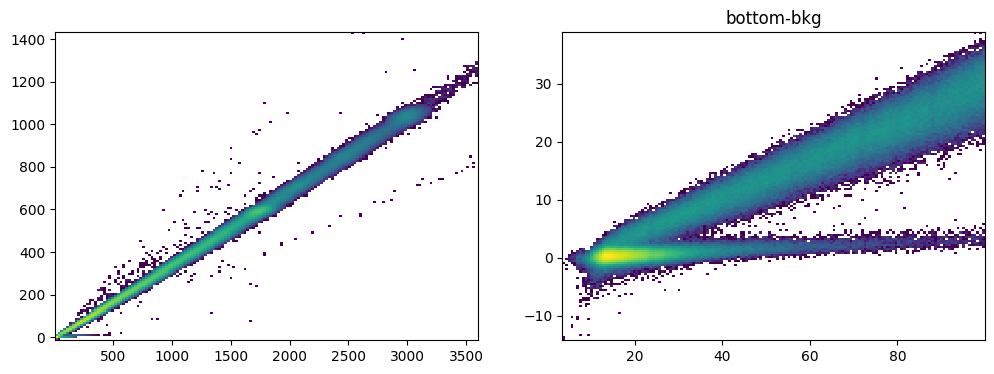

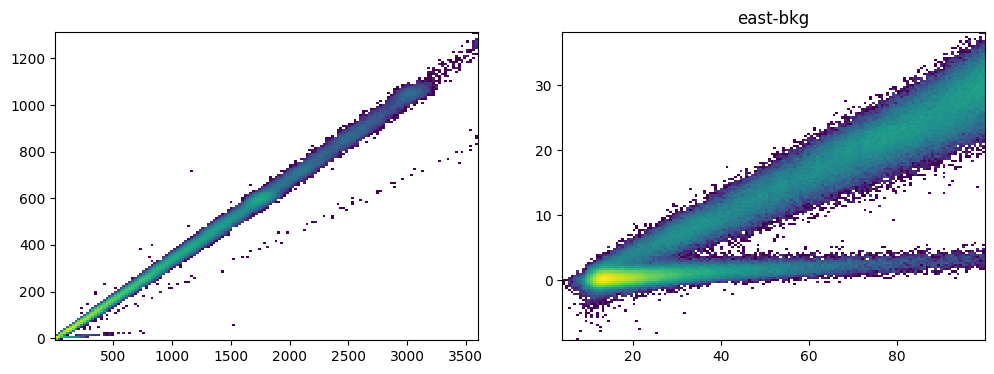

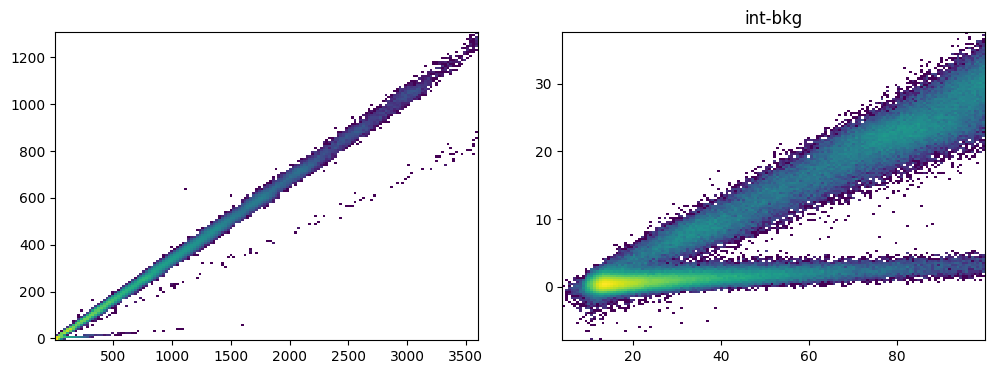

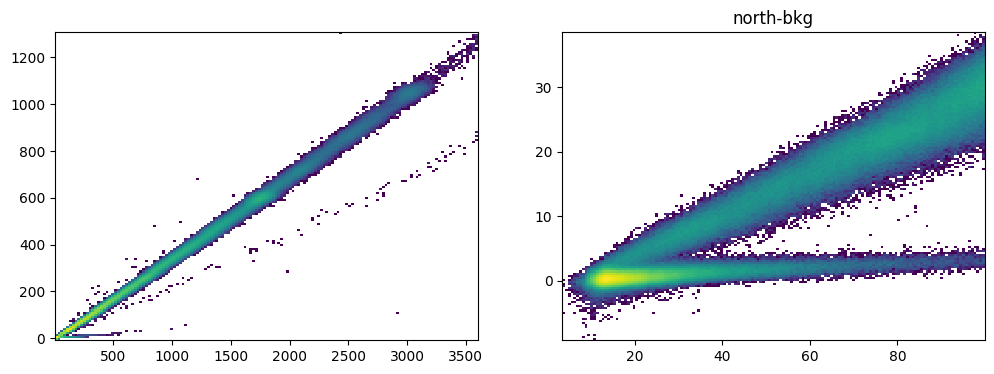

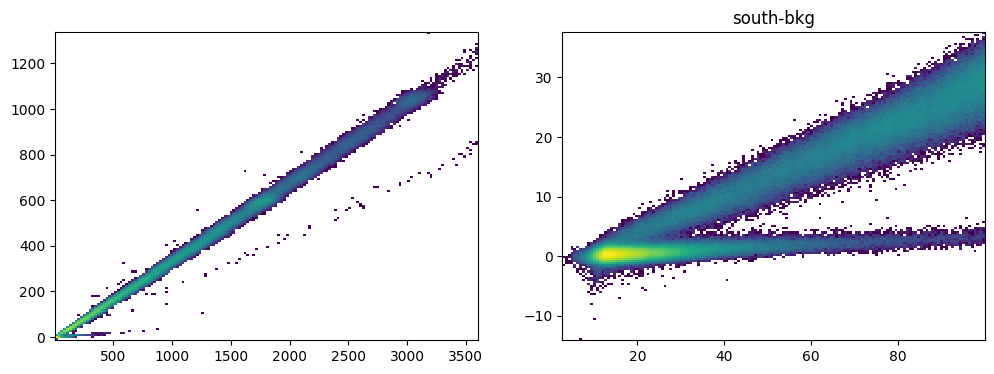

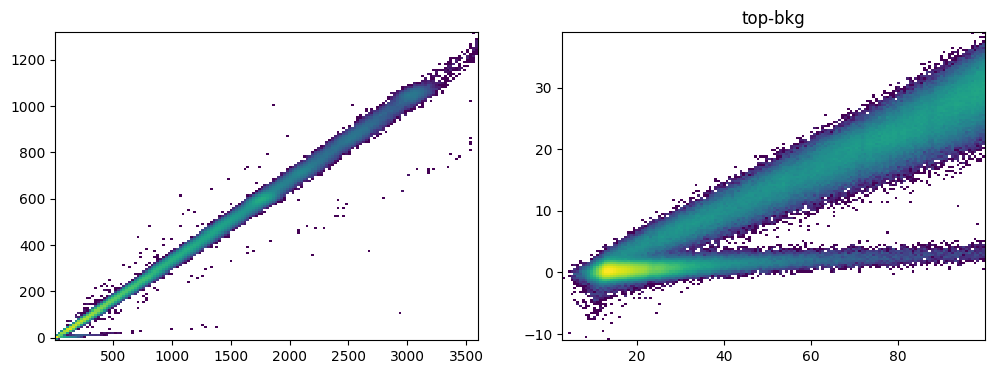

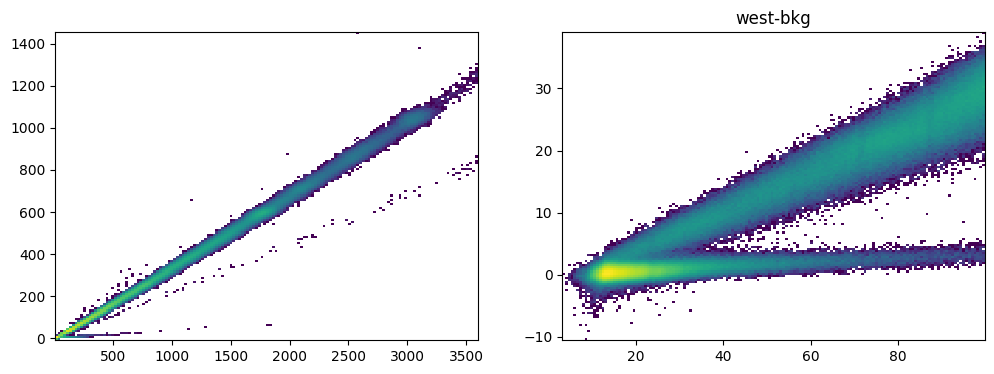

In [72]:
for key, event_matrix in event_dictionary.items():
    
    fig, ax = plt.subplots( 1, 2, figsize=(12,4))
    
    cuts = (event_matrix[:,4] < max_limit) & (event_matrix[:,6] > frac_above_middle) & (event_matrix[:,3] < std_threshold)

    cut_range = event_matrix[:,7] < 3600
    ax[0].hist2d( event_matrix[:,7][cuts & cut_range], event_matrix[:,8][cuts & cut_range], bins=(150,150), norm=matplotlib.colors.LogNorm())
    
    cut_range = event_matrix[:,7] < 100
    ax[1].hist2d( event_matrix[:,7][cuts & cut_range], event_matrix[:,8][cuts & cut_range], bins=(150,150), norm=matplotlib.colors.LogNorm())
    #ax[1].set_xlim( [0,100] )

    plt.title( key )
    plt.show()

#plt.yscale('log')
#plt.xlim([-10,1200])

#plt.minorticks_on()
#plt.grid( which='both')

#plt.xlabel('ADC count [a.u.]', fontsize=14)
#plt.ylabel('Count rate [Hz]', fontsize=14)



## High-Energy Region Below the Main Band

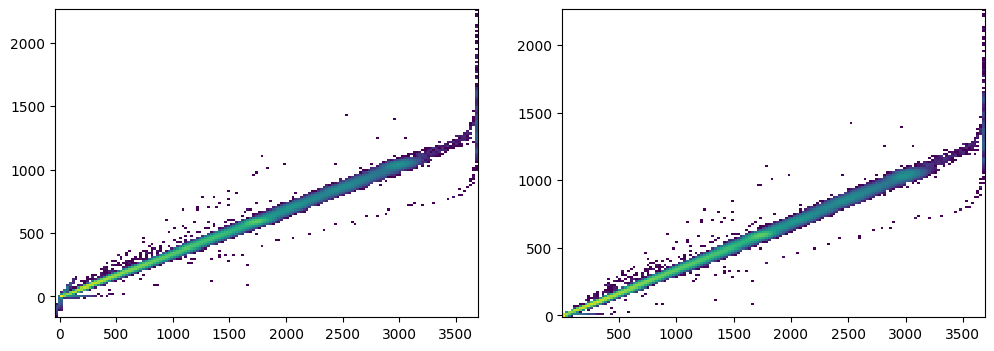

In [50]:
fig, ax = plt.subplots(1,2,figsize=(12,4))

ax[0].hist2d( event_matrix[:,7], event_matrix[:,8], bins=(150,150), norm=matplotlib.colors.LogNorm())
ax[1].hist2d( event_matrix[:,7][cuts], event_matrix[:,8][cuts], bins=(150,150), norm=matplotlib.colors.LogNorm())
plt.show()

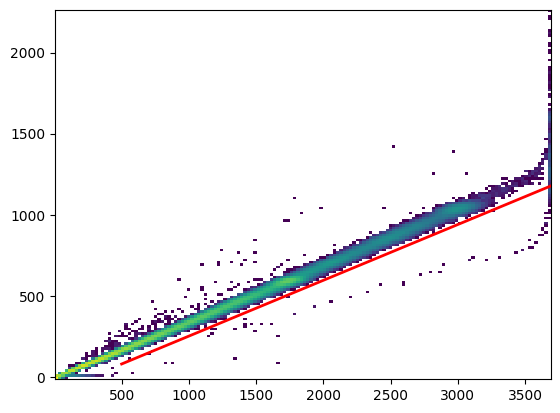

In [51]:
plt.figure()

mask = cuts & (event_matrix[:,7] < 4000)

plt.hist2d( event_matrix[:,7][mask], event_matrix[:,8][mask], bins=(150,150), norm=matplotlib.colors.LogNorm())

def HALE( x ):
    x1, x2 = [500,3000]
    y1, y2 = [80,940]
    return y1 + (y2-y1)/(x2-x1) * (x-x1)
    
def Cut_HALE( x, y ):
    return y - HALE(x) > 0
    
xrange = np.array([500, 4000])
plt.plot( xrange, HALE(xrange), color = 'red', lw = 2 )

plt.show()

mask = cuts & (event_matrix[:,7] < 4000) & (event_matrix[:,7] > 500) & ( Cut_HALE( event_matrix[:,7], event_matrix[:,8] )==False )

In [66]:
files = event_matrix[:,0][mask]
allowed_indices = event_matrix[:,1][mask]

print( files, allowed_indices )

find_file_by_run_id( 10, 'bottom', filedir)

[ 0.  0.  0.  0.  0.  0.  0. 10. 10. 10. 10. 10. 10. 11. 11. 11. 11. 11.
 12. 12. 12. 12. 12. 12. 12. 12. 12. 12. 12. 13. 13. 13. 13. 13. 13. 13.
 13. 13. 14. 14. 14. 14. 14. 14. 14. 14. 14. 14. 14. 14. 14. 15. 16. 16.
 16. 16. 16. 16. 16. 16. 16. 16. 17. 17. 17. 17. 17. 17. 17. 18. 18. 18.
 18. 18. 18. 18. 19. 19. 19. 19. 19. 19.  1.  1.  1.  1.  1. 20. 20. 20.
 20. 20. 20. 20. 20. 20. 20. 20. 20. 21. 21. 21. 21. 21. 21. 21.  2.  2.
  2.  2.  3.  3.  3.  3.  3.  3.  3.  3.  4.  4.  4.  4.  4.  4.  4.  4.
  5.  5.  5.  5.  5.  5.  5.  5.  5.  6.  6.  6.  6.  6.  6.  6.  6.  6.
  6.  6.  6.  7.  7.  7.  7.  7.  8.  8.  8.  8.  8.  8.  8.  8.  8.  9.
  9.  9.  9.  9.  9.  9.  9.  9.  9.  9.  9.] [ 76428.  88777. 103091. 115824. 119358. 140307. 157451.  46766.  70986.
  84020. 143285. 148966. 173015.   9148.  64721.  76304. 130328. 140658.
  29182.  34707.  46098.  52678.  52834.  75960. 106856. 107167. 145324.
 158119. 173526.  16984.  38256.  40273.  40411.  70267.  82253.  93875.
 1129

['data/20250325_NaI_Kamioka/NaI_Background_Bottom_Run10_HV800_20250325_211253.hdf5']

In [ ]:


slider = widgets.SelectionSlider(
    options=allowed_indices,
    value=allowed_indices[0],
    description='Event:',
    continuous_update=False,
    layout=widgets.Layout(width='70%'),
    style={'description_width': 'initial'}
)

# Create the output widget to hold the figure
out = widgets.Output()

# Function to update output
def on_slider_change(change):
    with out:
        out.clear_output(wait=True)
        plot_waveform(change['new'])
        print()

# Attach callback
slider.observe(on_slider_change, names='value')

# Display slider and output area
display(slider, out)

# Spectrum

To obtain the spectrum, all pulses are processed according to the following rule:
- check for good baseline, if std > 2, skip the event
- find the pulse begin by looking for the last 1-sigma deviation
- integrate from pulse begin - 4 samples for 2 us, and define this for primary pulse
- integrate from the end of the first primary integration window to end of the entire event (define as second event window)

In [6]:
result = []
    # result will be array of python tuples

counter = 0

std_threshold = 3
    # only select events with clean baseline

for event_data, event_attr in reader.GetEventIterator():
    
    print( "Processing event {}".format(event_attr["index"]), end='\r' )

    array_whole = event_data[channel]
    mean, dev = GetBaseline( array_whole, pre_trigger_window )

    if dev > std_threshold:
        counter += 1
            # since counter is used as index below, need to increment even if skipping event
        continue
        
    array_whole =  mean * np.ones( len(array_whole) ) - array_whole
        # use the entire array to calculate mean and fluctuation
    
    begin = GetPulseBegin( array_whole, pre_trigger_window, 1 )
    
    tmp = array_whole[ begin - 4 : begin + 500 ]

    energy1 = np.trapezoid(tmp) * 0.004
    height1 = np.max(tmp)
    
    tmp2 = array_whole[ begin + 500 : ]
    energy2 = np.trapezoid(tmp2) * 0.004
    height2 = np.max(tmp2)

    result.append( [counter, height1, energy1, height2, energy2] )
    
    counter += 1

result = np.array(result)

Processing event 173616

## Display Energy Spectrum

- Make a cut such that saturated pulses are not taken into account

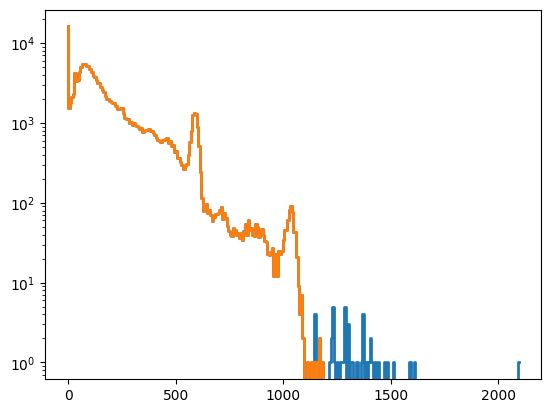

In [7]:
plt.figure()

counts1, bin_edges = np.histogram( result[:,2], bins=300 );
plt.step(bin_edges[:-1], counts1, where='mid', linewidth=2)
plt.yscale('log')

mask = (result[:,1] < 3500) & (result[:,1] > 0)
counts2, bin_edges = np.histogram( result[:,2][mask==True], bins=bin_edges);
plt.step(bin_edges[:-1], counts2, where='mid', linewidth=2)
plt.yscale('log')
#plt.xlim([0,70])
plt.show()

# Display Height-Energy 2D Histogram

- also draw lines that defines abnormal event regions

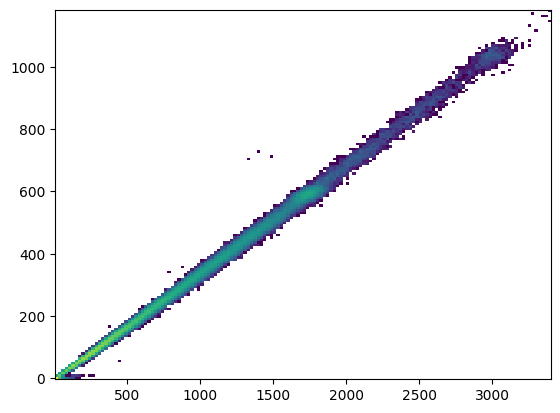

In [8]:
plt.figure()
mask = result[:,1] < 3500
plt.hist2d( result[:,1][mask], result[:,2][mask], bins=(150,150), norm=matplotlib.colors.LogNorm())
plt.show()

## High-energy region below the main band
- This region features same pulse height, but smaller integral
- It turns out to be due to a small pulse succeeded by a bigger pulse (similar to a Bi-Po event)
    - due to the way integral is done, pulses getting very close to the primary pulse is integrated into the primary region
    - if the pulse is more separated, then the main pulse is not entering the primary integral region (500 samples / 2 us)

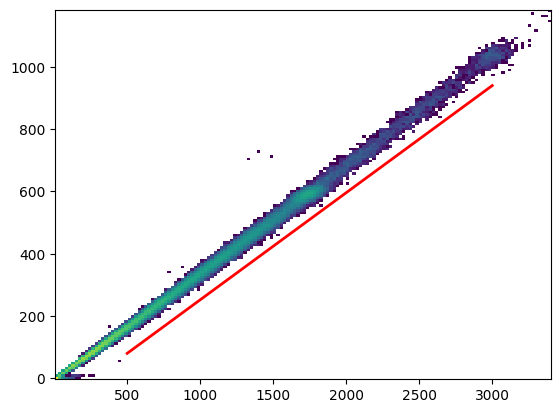

x=0, y=-92.0


In [9]:
plt.figure()
mask = result[:,1] < 3500
plt.hist2d( result[:,1][mask], result[:,2][mask], bins=(150,150), norm=matplotlib.colors.LogNorm())

def HALE( x ):
    x1, x2 = [500,3000]
    y1, y2 = [80,940]
    return y1 + (y2-y1)/(x2-x1) * (x-x1)

xrange = np.array([500, 3000])
plt.plot( xrange, HALE(xrange), color = 'red', lw = 2 )

plt.show()

print( 'x=0, y={}'.format(HALE(0)) )

In [10]:
def Cut_HALE( x, y ):
    return y - HALE(x) > 0

mask = (result[:,1] < 3000) & (result[:,1] > 500) & ( Cut_HALE( result[:,1], result[:,2] )==False )
event_list_hale = result[:,0][mask]
print( len(event_list_hale) )

0


In [11]:
NPlot = len(event_list_hale)

if NPlot != 0:
    
    #fig = plt.plot()
    fig, axes = plt.subplots( NPlot, 1, sharex=True, figsize=(8, 2 * NPlot), constrained_layout=True)

    # Ensure axes is a list even if N=1
    if NPlot == 1:
        axes = [axes]
        
    for n,id in enumerate(event_list_hale):
    
        event, event_attr = reader.GetEvent( int(id) )
        xdata = np.linspace(0, 0.004 * len(event[channel]), len(event[channel]) )
        axes[n].plot( xdata, event[channel], label='event ID {}'.format(int(id)) )
    
        if n >= NPlot-1:
            break;
    
    axes[-1].set_xlabel("Time [us]")
    plt.show()

## High-energy region above the main band
- This region features same pulse height, but larger integral, most likely due to pile-ups

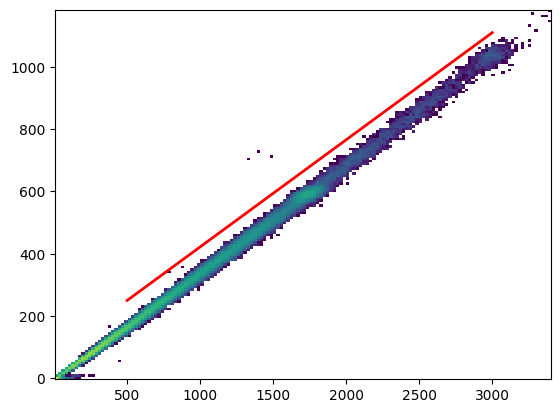

x=0, y=78.0


In [12]:
plt.figure()
mask = result[:,1] < 3500
plt.hist2d( result[:,1][mask], result[:,2][mask], bins=(150,150), norm=matplotlib.colors.LogNorm())

def HAHE( x ):
    x1, x2 = [500,3000]
    y1, y2 = [250,1110]
    return y1 + (y2-y1)/(x2-x1) * (x-x1)

xrange = np.array([500, 3000])
plt.plot( xrange, HAHE(xrange), color = 'red', lw = 2 )

plt.show()

print( 'x=0, y={}'.format(HAHE(0)) )

In [13]:
def Cut_HAHE( x, y ):
    return y - HAHE(x) < 0

mask = (result[:,1] < 3000) & (result[:,1] > 500) & ( Cut_HAHE( result[:,1], result[:,2] )==False )
event_list_hahe = result[:,0][mask]
print(len(event_list_hahe))

3


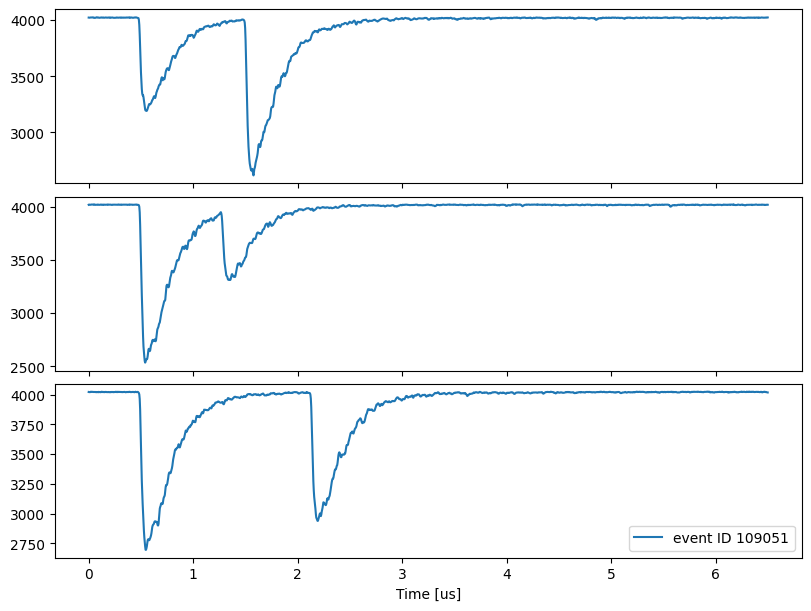

In [14]:
NPlot = len(event_list_hahe)

#fig = plt.plot()
fig, axes = plt.subplots( NPlot, 1, sharex=True, figsize=(8, 2 * NPlot), constrained_layout=True)

# Ensure axes is a list even if N=1
if NPlot == 1:
    axes = [axes]
    
for n,id in enumerate(event_list_hahe):

    event, event_attr = reader.GetEvent( int(id) )
    xdata = np.linspace(0, 0.004 * len(event[channel]), len(event[channel]) )
    axes[n].plot( xdata, event[channel], label='event ID {}'.format(int(id)) )

    if n >= NPlot-1:
        break;

axes[-1].set_xlabel("Time [us]")
plt.legend()
plt.show()

## Low-energy region below the main band
In this region, events consists of three categories:
1. pile-up events where the bigger pulse arrives around the end of integration window
    - so that pulse height is registered, but integral is not
    - these events have relatively larger integrals above ~20
2. sharp pulses corresponding to a few photons
    - these are probably Cerenkov events
4. noise that have sharp risetime


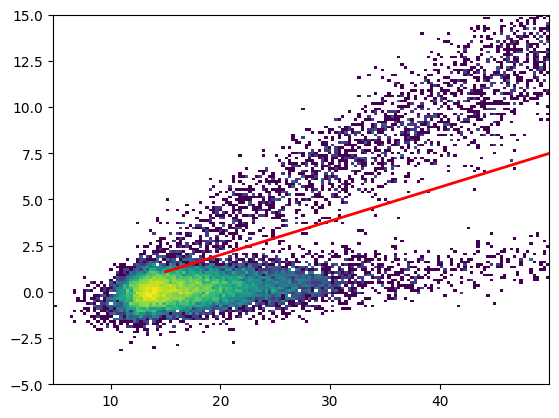

x=0, y=-1.6666666666666665


In [15]:
plt.figure()
mask = (result[:,1] < 50) #& (result[:,2] < 2.5)
plt.hist2d( result[:,1][mask], result[:,2][mask], bins=(150,150), norm=matplotlib.colors.LogNorm())

def LALE( x ):
    x1, x2 = [20,500]
    y1, y2 = [2,90]
    return y1 + (y2-y1)/(x2-x1) * (x-x1)

xrange = np.array([15, 500])
plt.plot( xrange, LALE(xrange), color = 'red', lw = 2 )
plt.ylim([-5,15])
plt.show()

print( 'x=0, y={}'.format(LALE(0)) )

In [16]:
def Cut_LALE( x, y ):
    return y - LALE(x) > 0

mask = (result[:,1] < 400) & (result[:,1] > 100) & ( Cut_LALE( result[:,1], result[:,2] )==False )
event_list_lale = result[:,0][mask]
print( len(event_list_lale) )

44


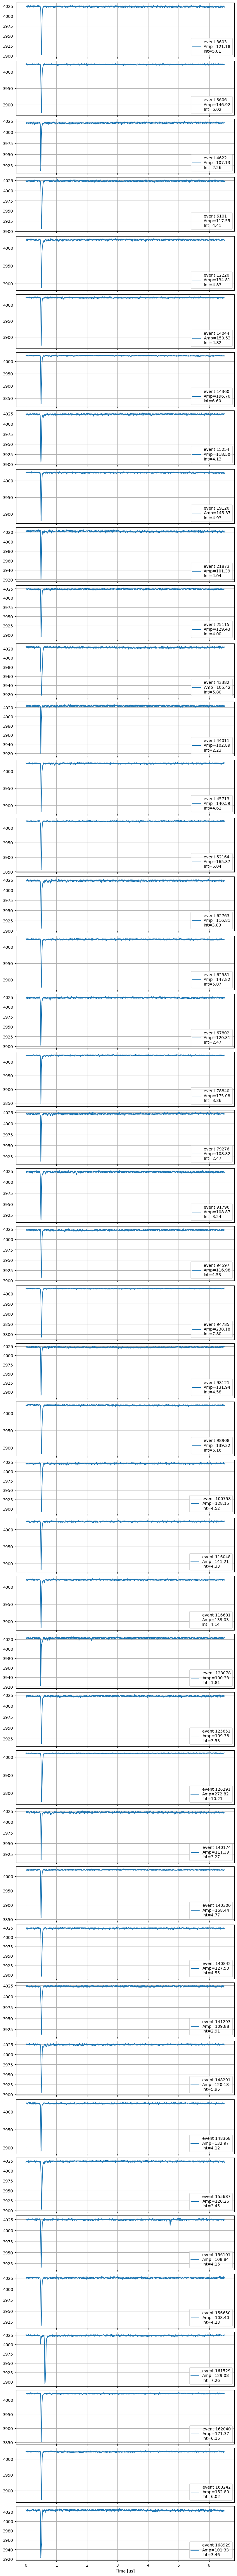

In [18]:
NPlot = len(event_list_lale)

#fig = plt.plot()
fig, axes = plt.subplots( NPlot, 1, sharex=True, figsize=(8, 2 * NPlot), constrained_layout=True)

# Ensure axes is a list even if N=1
if NPlot == 1:
    axes = [axes]
    
for n,id in enumerate(event_list_lale):
    
    id = int(id)
    
    event, event_attr = reader.GetEvent( id )
    xdata = np.linspace(0, 0.004 * len(event[channel]), len(event[channel]) )
    
    amp, ene = GetPulseHeightEnergy( event[channel], pre_trigger_window, 500)
    
    axes[n].plot( xdata, event[channel], label = 'event {}\nAmp={:.2f}\nInt={:.2f}'.format(id,amp,ene) )
    axes[n].legend(loc="lower right")  # Set legend position
    axes[n].grid(True)

    if n >= NPlot-1:
        break;

axes[-1].set_xlabel("Time [us]")
plt.legend()
plt.show()

## Low-energy region above the main band
Events in this region is still dominated by pile-ups.


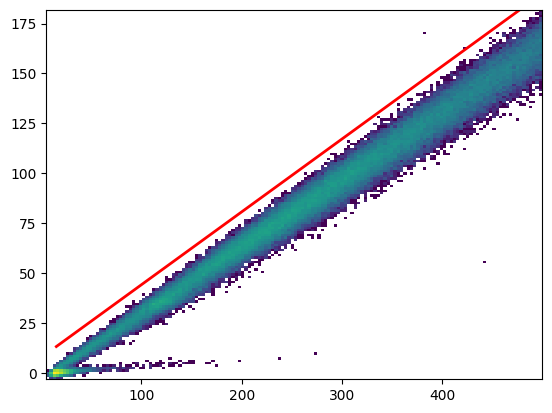

x=0, y=7.708333333333334


In [19]:
plt.figure()
mask = (result[:,1] < 500) #& (result[:,2] < 2.5)
plt.hist2d( result[:,1][mask], result[:,2][mask], bins=(150,150), norm=matplotlib.colors.LogNorm())

def LAHE( x ):
    x1, x2 = [20,500]
    y1, y2 = [15,190]
    return y1 + (y2-y1)/(x2-x1) * (x-x1)

xrange = np.array([15, 500])
plt.plot( xrange, LAHE(xrange), color = 'red', lw = 2 )

plt.show()

print( 'x=0, y={}'.format(LAHE(0)) )

In [20]:
def Cut_LAHE( x, y ):
    return y - LAHE(x) < 0

mask = (result[:,1] < 400) & (result[:,1] > 100) & ( Cut_LAHE( result[:,1], result[:,2] )==False )
event_list_lahe = result[:,0][mask]
print( len(event_list_lahe) )

1


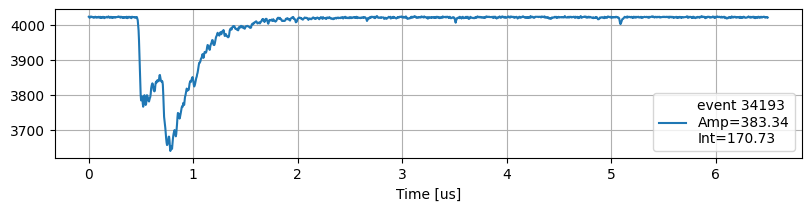

In [21]:
NPlot = len(event_list_lahe)

#fig = plt.plot()
fig, axes = plt.subplots( NPlot, 1, sharex=True, figsize=(8, 2 * NPlot), constrained_layout=True)

# Ensure axes is a list even if N=1
if NPlot == 1:
    axes = [axes]
    
for n,id in enumerate(event_list_lahe):
    
    id = int(id)
    
    event, event_attr = reader.GetEvent( id )
    xdata = np.linspace(0, 0.004 * len(event[channel]), len(event[channel]) )
    
    amp, ene = GetPulseHeightEnergy( event[channel], pre_trigger_window, 500)
    
    axes[n].plot( xdata, event[channel], label = 'event {}\nAmp={:.2f}\nInt={:.2f}'.format(id,amp,ene) )
    axes[n].legend(loc="lower right")  # Set legend position
    axes[n].grid(True)

    if n >= NPlot-1:
        break;

axes[-1].set_xlabel("Time [us]")
plt.legend()
plt.show()

In [22]:
reader.Close()